<a href="https://colab.research.google.com/github/kridtapon/Revert-Cross-Strategy/blob/main/Revert_%26_Cross_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.6/527.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.5 MB/s eta 0:00:00


In [ ]:
pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.8/113.8 kB 2.0 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.56
    Uninstalling yfinance-0.2.56:
      Successfully uninstalled yfinance-0.2.56


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt

# Function to calculate EMA Trend
def calculate_ema_trend(df, fast_period=20, slow_period=50):
    df['EMA_fast'] = df['Close'].ewm(span=fast_period).mean()
    df['EMA_slow'] = df['Close'].ewm(span=slow_period).mean()
    df['EMA_Trend'] = df['EMA_fast'] > df['EMA_slow']  # True for green, False for red

# Function to calculate RSI
def calculate_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    df['RSI'] = rsi

# Define the stock symbol and time period
symbol = 'MCK'
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download the data
df = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# Calculate RSI and TTM Trend
calculate_rsi(df, period=14)
calculate_ema_trend(df, fast_period=20, slow_period=50)

# Filter data for the test period (2020-2025)
df = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

# Define Entry and Exit signals based on RSI + TTM Trend strategy
df['Entry'] = (df['RSI'] < 30) & df['EMA_Trend']
df['Exit'] = (df['RSI'] > 70) & (~df['EMA_Trend'])

# Shift entries and exits to next bar
shifted_entries = df['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
shifted_exits = df['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

# Create portfolio using 'Open' prices
portfolio = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shifted_entries,
    exits=shifted_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

# Display performance metrics
print(portfolio.stats())

# Plot equity curve
portfolio.plot().show()


[*********************100%***********************]  1 of 1 completed
<ipython-input-19-8bc69257dc56>:46: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-19-8bc69257dc56>:47: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Start                         2020-01-02 00:00:00
End                           2024-12-31 00:00:00
Period                         1258 days 00:00:00
Start Value                              100000.0
End Value                           333542.255451
Total Return [%]                       233.542255
Benchmark Return [%]                   326.834909
Max Gross Exposure [%]                      100.0
Total Fees Paid                       1328.544202
Max Drawdown [%]                        24.796201
Max Drawdown Duration           234 days 00:00:00
Total Trades                                    3
Total Closed Trades                             2
Total Open Trades                               1
Open Trade PnL                        -5119.06654
Win Rate [%]                                100.0
Best Trade [%]                         175.835775
Worst Trade [%]                         22.877524
Avg Winning Trade [%]                   99.356649
Avg Losing Trade [%]                          NaN


Streaming output truncated to the last 5000 lines.
<ipython-input-24-9af60d3fbd83>:59: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-24-9af60d3fbd83>:60: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-24-9af60d3fbd83>:55: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-24-9

Best Parameters: Fast Period = 27, Slow Period = 196, RSI Period = 30


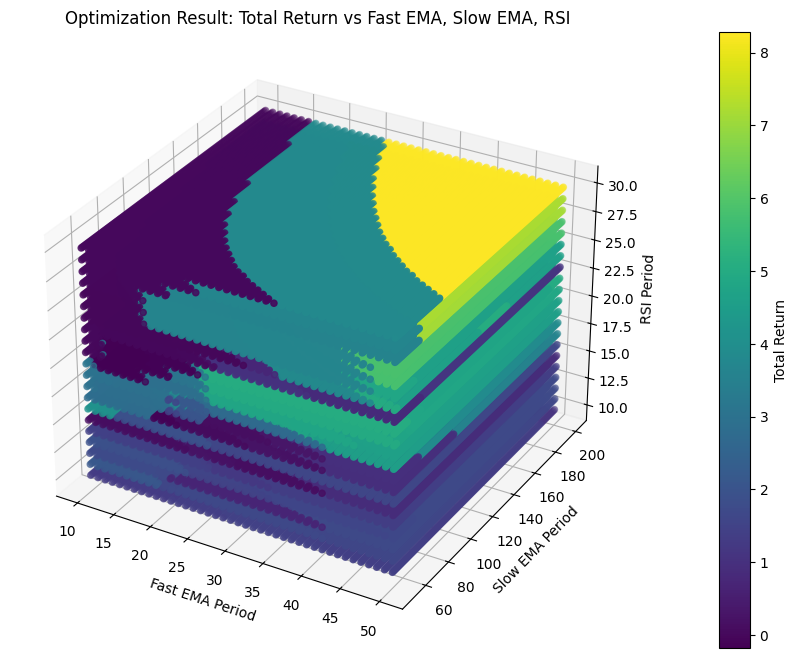

<ipython-input-24-9af60d3fbd83>:125: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-24-9af60d3fbd83>:126: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-24-9af60d3fbd83>:129: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-24-9af60d3fbd83>:130: Future

Start                         2020-01-02 00:00:00
End                           2024-12-31 00:00:00
Period                         1258 days 00:00:00
Start Value                              100000.0
End Value                            928388.59463
Total Return [%]                       828.388595
Benchmark Return [%]                   433.864733
Max Gross Exposure [%]                      100.0
Total Fees Paid                        484.053737
Max Drawdown [%]                        37.061481
Max Drawdown Duration           329 days 00:00:00
Total Trades                                    2
Total Closed Trades                             1
Total Open Trades                               1
Open Trade PnL                      736311.967959
Win Rate [%]                                100.0
Best Trade [%]                          92.168703
Worst Trade [%]                         92.168703
Avg Winning Trade [%]                   92.168703
Avg Losing Trade [%]                          NaN


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools

# Function to calculate EMA Trend
def calculate_ema_trend(df, fast_period=20, slow_period=50):
    df['EMA_fast'] = df['Close'].ewm(span=fast_period).mean()
    df['EMA_slow'] = df['Close'].ewm(span=slow_period).mean()
    df['EMA_Trend'] = df['EMA_fast'] > df['EMA_slow']  # True for green, False for red

# Function to calculate RSI
def calculate_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    df['RSI'] = rsi

# Define the stock symbol and time period
symbol = 'FICO'
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download the data
df = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# Define parameter ranges
fast_periods = range(10, 51)
slow_periods = range(51, 201)
rsi_periods = range(10, 31)

# Initialize the results storage
results = np.zeros((len(fast_periods), len(slow_periods), len(rsi_periods)))

# Use itertools.product to loop over combinations
for i, (fast_period, slow_period, rsi_period) in enumerate(itertools.product(fast_periods, slow_periods, rsi_periods)):
    # Calculate RSI and TTM Trend with current parameters
    calculate_rsi(df, period=rsi_period)
    calculate_ema_trend(df, fast_period=fast_period, slow_period=slow_period)

    # Filter data for the test period (2020-2025)
    df_test = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

    # Define Entry and Exit signals based on RSI + TTM Trend strategy
    df_test['Entry'] = (df_test['RSI'] < 30) & df_test['EMA_Trend']
    df_test['Exit'] = (df_test['RSI'] > 70) & (~df_test['EMA_Trend'])

    # Shift entries and exits to next bar
    shifted_entries = df_test['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
    shifted_exits = df_test['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

    # Create portfolio using 'Open' prices
    portfolio = vbt.Portfolio.from_signals(
        close=df_test['Open'],
        entries=shifted_entries,
        exits=shifted_exits,
        init_cash=100_000,
        fees=0.001,
        slippage=0.002,
        freq='D'
    )

    # Store the final portfolio value (or any metric of interest)
    results[i // (len(slow_periods) * len(rsi_periods)), (i // len(rsi_periods)) % len(slow_periods), i % len(rsi_periods)] = portfolio.total_return()

# Find the best parameter combination
best_idx = np.unravel_index(np.argmax(results), results.shape)
best_fast = fast_periods[best_idx[0]]
best_slow = slow_periods[best_idx[1]]
best_rsi = rsi_periods[best_idx[2]]

# Print the best parameters
print(f"Best Parameters: Fast Period = {best_fast}, Slow Period = {best_slow}, RSI Period = {best_rsi}")

# ---- ADD 3D PLOT of all optimized parameters ----

# Prepare data for 3D plot
X, Y, Z = [], [], []
Returns = []

for i, fast in enumerate(fast_periods):
    for j, slow in enumerate(slow_periods):
        for k, rsi in enumerate(rsi_periods):
            X.append(fast)
            Y.append(slow)
            Z.append(rsi)
            Returns.append(results[i, j, k])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(X, Y, Z, c=Returns, cmap='viridis', marker='o')

# Color bar to show return scale
cbar = fig.colorbar(sc, pad=0.1)
cbar.set_label('Total Return')

# Labels
ax.set_xlabel('Fast EMA Period')
ax.set_ylabel('Slow EMA Period')
ax.set_zlabel('RSI Period')
ax.set_title('Optimization Result: Total Return vs Fast EMA, Slow EMA, RSI')

plt.show()

# Backtest with the best parameters
calculate_rsi(df, period=best_rsi)
calculate_ema_trend(df, fast_period=best_fast, slow_period=best_slow)

# Filter data for the test period (2020-2025)
df = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

# Define Entry and Exit signals with the best parameters
df['Entry'] = (df['RSI'] < 30) & df['EMA_Trend']
df['Exit'] = (df['RSI'] > 70) & (~df['EMA_Trend'])

# Shift entries and exits to next bar
shifted_entries = df['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
shifted_exits = df['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

# Create portfolio using 'Open' prices
portfolio = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shifted_entries,
    exits=shifted_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

# Display performance metrics of the backtest with the best parameters
print(portfolio.stats())

# Plot equity curve
portfolio.plot().show()

